# S6E5 — Tuning dos Modelos

## Setup

### Imports e configuração

In [1]:
from pathlib import Path

import pandas as pd
import optuna
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from mltemplate.config import ProjectConfig
from mltemplate.storage import StorageManager
from mltemplate.data import KaggleSource, DataManager
from mltemplate.tuning import OptunaTuner, XGBoostAdapter, LightGBMAdapter, KerasAdapter

import logging
logging.basicConfig(level=logging.INFO)

d:\data_science\kaggle_competitions\S6E5-predicting_f1_pit_stops\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = ProjectConfig(
    target="PitNextLap",                                                                                                                                                                   # ajuste para o nome real da coluna alvo
    numerical_features=["Year", "LapNumber", "Stint", "TyreLife", "Position", "LapTime (s)", "LapTime_Delta", "Cumulative_Degradation", "RaceProgress", "Position_Change"],                # preencha após ver o dataset
    categorical_features=["Compound", "Race", "PitStop"],                                                                                                                                  # preencha após ver o dataset
    ignore_features=["id", "Driver"],                                                                                                                                                                # ajuste se necessário
    problem_type="classification",
)

storage = StorageManager(root=Path("."))
dm      = DataManager(storage, config)

### Carregar feature set

In [3]:
X_train_v1, X_test_v1, y_train_v1, X_val_v1, y_val_v1, y_test_v1 = dm.load_feature_set(name="v1")

print(f"X_train_v1: {X_train_v1.shape}")
print(f"X_val_v1:   {X_val_v1.shape}")
print(f"X_test_v1:  {X_test_v1.shape}")

INFO:mltemplate.data.manager:Feature set 'v1' carregado — treino (351312, 42), teste (188165, 42)


X_train_v1: (351312, 42)
X_val_v1:   (87828, 42)
X_test_v1:  (188165, 42)


## v1 — XGBoost

### Tuning

In [6]:
def xgb_param_space_v1(trial: optuna.Trial) -> dict:
    return {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 3000),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    }

result_xgb_v1 = OptunaTuner(config).tune(
    XGBoostAdapter(XGBClassifier),
    X_train_v1, y_train_v1,
    param_space_func = xgb_param_space_v1,
    scoring="roc_auc",
    X_val = X_val_v1, 
    y_val = y_val_v1,
    n_trials = 150,
    timeout = 7200
)

print(f"XGB — ROC-AUC (val): {result_xgb_v1.score:.4f}")
print(f"Params: {result_xgb_v1.params}")

INFO:mltemplate.tuning.tuner:OptunaTuner — modo holdout, scoring=roc_auc, n_trials=150
Melhor: 0.9498:  55%|█████▍    | 82/150 [2:01:33<1:40:48, 88.95s/it] 


XGB — ROC-AUC (val): 0.9498
Params: {'n_estimators': 2168, 'max_depth': 10, 'learning_rate': 0.010522300722248603, 'subsample': 0.8704167662162621, 'colsample_bytree': 0.5277994742111378, 'reg_alpha': 1.616742951645964e-07, 'reg_lambda': 0.0028620858213456576, 'min_child_weight': 10}


,trial,score,delta,best_so_far
0,0,0.942858,NaN,0.942858
1,1,0.949443,6.584935e-03,0.949443
2,22,0.949459,1.593489e-05,0.949459
3,35,0.949479,2.030791e-05,0.949479
4,43,0.949480,2.797950e-07,0.949480
5,54,0.949560,8.067978e-05,0.949560
6,62,0.949601,4.036206e-05,0.949601
7,70,0.949694,9.348488e-05,0.949694
8,76,0.949707,1.300193e-05,0.949707
9,78,0.949738,3.098038e-05,0.949738


C:\Users\lucia\AppData\Local\Temp\ipykernel_23328\3796331567.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


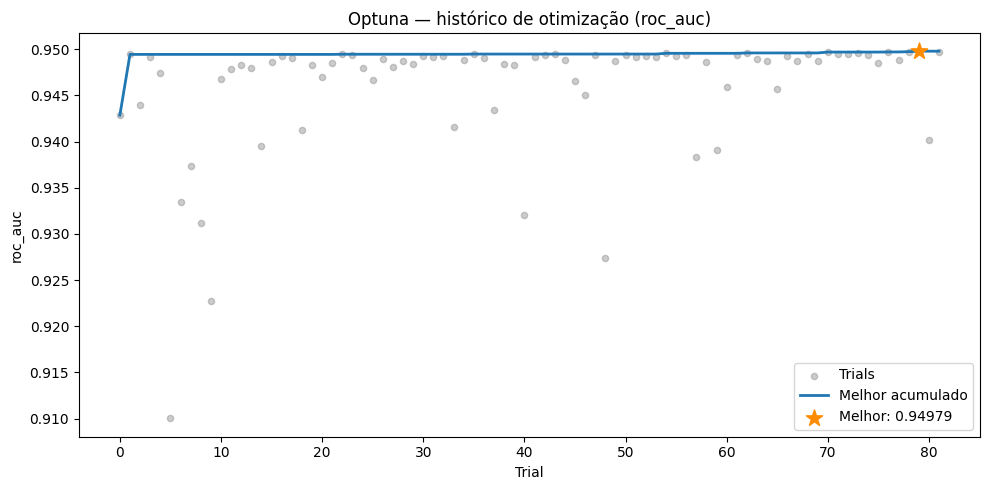

In [7]:
display(result_xgb_v1.improvement_table())

fig = result_xgb_v1.plot_optimization_history()
fig.show()

### Salvar

In [8]:
storage.save_model(result_xgb_v1.model, "xgb_v1")
storage.save_metrics({"roc_auc": result_xgb_v1.score, "params": result_xgb_v1.params}, "xgb_v1")
print("Modelo e métricas XGB salvos.")

INFO:mltemplate.storage:Modelo salvo em models\xgb_v1.pkl
INFO:mltemplate.storage:Métricas salvas em reports\metrics\xgb_v1.json


Modelo e métricas XGB salvos.


### Submissão

In [9]:
proba_preds = result_xgb_v1.model.predict_proba(X_test_v1)[:, 1]
_, test_df  = dm.load_raw(KaggleSource("playground-series-s6e5"))
submission  = pd.DataFrame({"id": test_df["id"], config.target: proba_preds})
storage.save_submission(submission, "xgb_v1")
print(f"Submissão salva em: {storage.submissions_path / 'xgb_v1.csv'}")
submission.head()

INFO:mltemplate.data.sources:Dados já existentes em data\raw — download ignorado.
INFO:mltemplate.data.manager:Dados brutos carregados — treino (439140, 16), teste (188165, 15)


Submissão salva em: submissions\xgb_v1.csv


,id,PitNextLap
0,439140,0.003547
1,439141,0.004233
2,439142,0.003013
3,439143,0.193722
4,439144,0.905095


## v1 — LightGBM

### Tuning

In [10]:
def lgbm_param_space_v1(trial: optuna.Trial) -> dict:
    return {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 300),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }

result_lgbm_v1 = OptunaTuner(config).tune(
    LightGBMAdapter(LGBMClassifier),
    X_train_v1, 
    y_train_v1,
    param_space_func = lgbm_param_space_v1,
    scoring = "roc_auc",
    X_val = X_val_v1, 
    y_val = y_val_v1,
    n_trials = 200,
)

print(f"LGBM — ROC-AUC (val): {result_lgbm_v1.score:.4f}")
print(f"Params: {result_lgbm_v1.params}")

INFO:mltemplate.tuning.tuner:OptunaTuner — modo holdout, scoring=roc_auc, n_trials=200
Melhor: 0.9496:  84%|████████▍ | 169/200 [1:00:09<11:02, 21.36s/it]


LGBM — ROC-AUC (val): 0.9496
Params: {'n_estimators': 983, 'max_depth': 9, 'learning_rate': 0.04912611962457605, 'num_leaves': 178, 'subsample': 0.6633008729024914, 'colsample_bytree': 0.542180330749588, 'reg_alpha': 4.022405704304847e-07, 'reg_lambda': 4.907070579021029, 'min_child_samples': 80}


,trial,score,delta,best_so_far
0,0,0.936580,NaN,0.936580
1,1,0.941109,0.004529,0.941109
2,2,0.945448,0.004339,0.945448
3,6,0.948204,0.002756,0.948204
4,9,0.948518,0.000314,0.948518
5,11,0.948721,0.000203,0.948721
6,12,0.948922,0.000201,0.948922
7,13,0.949018,0.000096,0.949018
8,51,0.949043,0.000026,0.949043
9,61,0.949073,0.000030,0.949073


C:\Users\lucia\AppData\Local\Temp\ipykernel_23328\1611211053.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


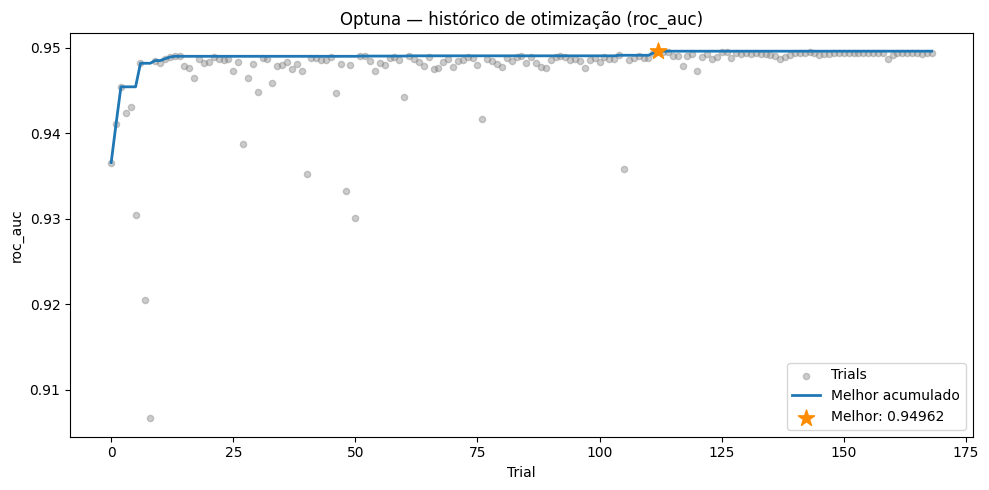

In [11]:
display(result_lgbm_v1.improvement_table())

fig = result_lgbm_v1.plot_optimization_history()
fig.show()

### Salvar

In [12]:
storage.save_model(result_lgbm_v1.model, "lgbm_v1")
storage.save_metrics({"roc_auc": result_lgbm_v1.score, "params": result_lgbm_v1.params}, "lgbm_v1")
print("Modelo e métricas LGBM salvos.")

INFO:mltemplate.storage:Modelo salvo em models\lgbm_v1.pkl
INFO:mltemplate.storage:Métricas salvas em reports\metrics\lgbm_v1.json


Modelo e métricas LGBM salvos.


### Submissão

In [13]:
proba_preds = result_lgbm_v1.model.predict_proba(X_test_v1)[:, 1]
_, test_df  = dm.load_raw(KaggleSource("playground-series-s6e5"))
submission  = pd.DataFrame({"id": test_df["id"], config.target: proba_preds})
storage.save_submission(submission, "lgbm_v1")
print(f"Submissão salva em: {storage.submissions_path / 'lgbm_v1.csv'}")
submission.head()

INFO:mltemplate.data.sources:Dados já existentes em data\raw — download ignorado.
INFO:mltemplate.data.manager:Dados brutos carregados — treino (439140, 16), teste (188165, 15)


Submissão salva em: submissions\lgbm_v1.csv


,id,PitNextLap
0,439140,0.005002
1,439141,0.004227
2,439142,0.002534
3,439143,0.216451
4,439144,0.908575


## v1 — Keras

### Tuning

In [14]:
def keras_param_space_v1(trial: optuna.Trial) -> dict:
    return {
        "n_layers":      trial.suggest_int("n_layers", 1, 4),
        "hidden_dim":    trial.suggest_categorical("hidden_dim", [64, 128, 256, 512]),
        "dropout":       trial.suggest_float("dropout", 0.0, 0.5),
        "activation":    trial.suggest_categorical("activation", ["relu"]),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "batch_size":    trial.suggest_categorical("batch_size", [256, 512, 1024]),
        "epochs":        100,
        "patience":      10,
    }

result_keras_v1 = OptunaTuner(config).tune(
    KerasAdapter(config),
    X_train_v1, y_train_v1,
    param_space_func=keras_param_space_v1,
    scoring="roc_auc",
    X_val=X_val_v1, y_val=y_val_v1,
    n_trials = 100,
    timeout = 7200
)

print(f"Keras — ROC-AUC (val): {result_keras_v1.score:.4f}")
print(f"Params: {result_keras_v1.params}")

INFO:mltemplate.tuning.tuner:OptunaTuner — modo holdout, scoring=roc_auc, n_trials=100
Melhor: 0.9452:  22%|██▏       | 22/100 [2:03:37<7:18:17, 337.15s/it] 


Keras — ROC-AUC (val): 0.9452
Params: {'n_layers': 4, 'hidden_dim': 128, 'dropout': 0.18408922630201843, 'activation': 'relu', 'learning_rate': 0.0002796988342118474, 'batch_size': 1024, 'epochs': 100, 'patience': 10}


,trial,score,delta,best_so_far
0,0,0.939088,NaN,0.939088
1,1,0.943784,0.004696,0.943784
2,3,0.944571,0.000787,0.944571
3,11,0.945191,0.000620,0.945191


C:\Users\lucia\AppData\Local\Temp\ipykernel_23328\3305558645.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


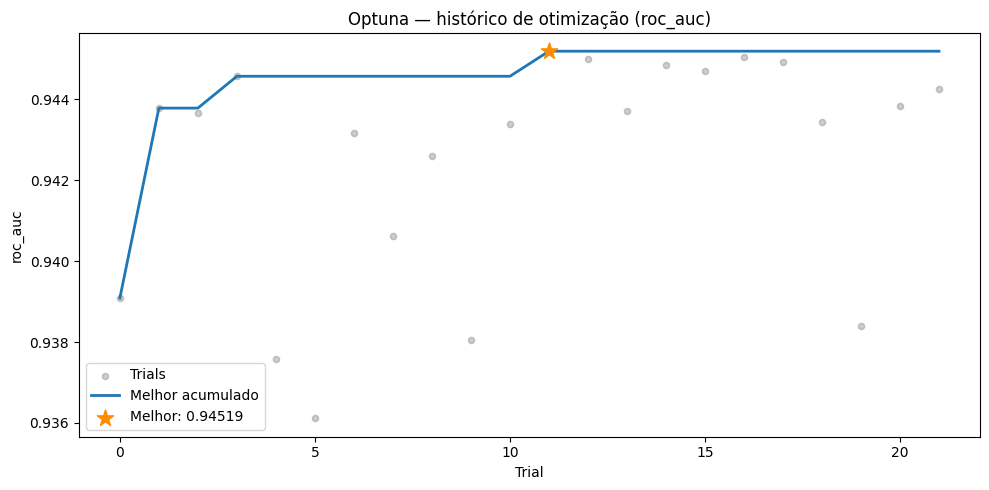

In [15]:
display(result_keras_v1.improvement_table())

fig = result_keras_v1.plot_optimization_history()
fig.show()

### Salvar

In [16]:
storage.save_model(result_keras_v1.model, "keras_v1")
storage.save_metrics({"roc_auc": result_keras_v1.score, "params": result_keras_v1.params}, "keras_v1")
print("Modelo e métricas Keras salvos.")

INFO:mltemplate.storage:Modelo salvo em models\keras_v1.pkl
INFO:mltemplate.storage:Métricas salvas em reports\metrics\keras_v1.json


Modelo e métricas Keras salvos.


### Submissão

In [17]:
proba_preds = result_keras_v1.model.predict_proba(X_test_v1)[:, 1]
_, test_df  = dm.load_raw(KaggleSource("playground-series-s6e5"))
submission  = pd.DataFrame({"id": test_df["id"], config.target: proba_preds})
storage.save_submission(submission, "keras_v1")
print(f"Submissão salva em: {storage.submissions_path / 'keras_v1.csv'}")
submission.head()

INFO:mltemplate.data.sources:Dados já existentes em data\raw — download ignorado.
INFO:mltemplate.data.manager:Dados brutos carregados — treino (439140, 16), teste (188165, 15)


Submissão salva em: submissions\keras_v1.csv


,id,PitNextLap
0,439140,0.011786
1,439141,0.037132
2,439142,0.010593
3,439143,0.281460
4,439144,0.858494
